# 02 — Well deliverability diagnostics agent

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/EvenSol/NeqSim-Colab/blob/master/notebooks/AI/community_agent_demos/02_well_deliverability_diagnostics_agent.ipynb)

Separate reservoir, completion, tubing, and facility causes with a reproducible nodal-analysis screen.

This is a **synthetic public demonstration**, not an autonomous-control
system. The agent prepares a traceable engineering screening package;
a qualified engineer owns assumptions, validation, and decisions.


## Agent contract

**Inputs:** reservoir and separator pressure, test rate, completion
state, tubing geometry, and fluid composition. **Outputs:** operating
point, scenario residuals, likely constraint, and next test.

Gas inflow is screened with
$q=C(p_r^2-p_{wf}^2)^n$ and the vertical-lift proxy with
$p_{wf}=\sqrt{p_s^2+a q^2+bq}$.

Deep dive: [well nodal analysis and VFP](../../well/well_nodal_analysis_and_eclipse_vfp.ipynb).


In [1]:
from importlib.metadata import PackageNotFoundError, version
from pathlib import Path
import hashlib
import os
import platform
import subprocess
import sys


REQUIRED_PACKAGES = {
    "neqsim": "3.17.0",
    "numpy": "2.5.2",
    "pandas": "3.0.5",
    "matplotlib": "3.11.1",
    "scipy": "1.18.0",
}
install_specs = []
for package_name, required_version in REQUIRED_PACKAGES.items():
    try:
        installed_version = version(package_name)
    except PackageNotFoundError:
        installed_version = None
    if installed_version != required_version:
        install_specs.append(f"{package_name}=={required_version}")

if install_specs:
    subprocess.run(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "--quiet",
            "--no-cache-dir",
            *install_specs,
        ],
        check=True,
    )

NEQSIM_SOURCE_REF = "master"
NEQSIM_SOURCE_REPOSITORY = "https://github.com/equinor/neqsim.git"
SOURCE_ROOT = Path(
    os.environ.get("NEQSIM_SOURCE_ROOT", "/content/neqsim-main")
).resolve()
SOURCE_JAR_OVERRIDE = os.environ.get("NEQSIM_SOURCE_JAR")
RUNTIME_DEPENDENCY_JAR = os.environ.get("NEQSIM_RUNTIME_DEPENDENCY_JAR")
using_local_source = "NEQSIM_SOURCE_ROOT" in os.environ

if not (SOURCE_ROOT / ".git").is_dir():
    subprocess.run(
        [
            "git",
            "clone",
            "--quiet",
            "--depth",
            "1",
            "--branch",
            NEQSIM_SOURCE_REF,
            NEQSIM_SOURCE_REPOSITORY,
            str(SOURCE_ROOT),
        ],
        check=True,
    )
elif not using_local_source:
    subprocess.run(
        [
            "git",
            "-C",
            str(SOURCE_ROOT),
            "fetch",
            "--quiet",
            "--depth",
            "1",
            "origin",
            NEQSIM_SOURCE_REF,
        ],
        check=True,
    )
    subprocess.run(
        [
            "git",
            "-C",
            str(SOURCE_ROOT),
            "checkout",
            "--quiet",
            "--detach",
            "FETCH_HEAD",
        ],
        check=True,
    )

NEQSIM_SOURCE_COMMIT = subprocess.check_output(
    ["git", "-C", str(SOURCE_ROOT), "rev-parse", "HEAD"],
    text=True,
).strip()

if SOURCE_JAR_OVERRIDE:
    SOURCE_JAR = Path(SOURCE_JAR_OVERRIDE).resolve()
    SOURCE_BUILD_KIND = os.environ.get(
        "NEQSIM_SOURCE_BUILD_KIND", "prebuilt source JAR override"
    )
else:
    jar_candidates = [
        path
        for path in (SOURCE_ROOT / "target").glob("neqsim-*.jar")
        if not any(
            marker in path.name
            for marker in ("sources", "javadoc", "tests", "original")
        )
    ]
    if not jar_candidates:
        subprocess.run(
            [
                str(SOURCE_ROOT / "mvnw"),
                "-q",
                "-DskipTests",
                "-Dmaven.javadoc.skip=true",
                "package",
            ],
            cwd=SOURCE_ROOT,
            check=True,
        )
        jar_candidates = [
            path
            for path in (SOURCE_ROOT / "target").glob("neqsim-*.jar")
            if not any(
                marker in path.name
                for marker in ("sources", "javadoc", "tests", "original")
            )
        ]
    if not jar_candidates:
        raise FileNotFoundError(
            "The NeqSim master source build did not produce a runtime JAR."
        )
    SOURCE_JAR = sorted(jar_candidates, key=lambda path: len(path.name))[0]
    SOURCE_BUILD_KIND = "Maven package from current master"

SOURCE_JAR_SHA256 = hashlib.sha256(SOURCE_JAR.read_bytes()).hexdigest()
os.environ["NEQSIM_JVM_AUTOSTART"] = "0"
os.environ.setdefault("MPLCONFIGDIR", "/tmp/neqsim-agent-demo-matplotlib")

import jpype


if jpype.isJVMStarted():
    raise RuntimeError(
        "The JVM started before the NeqSim master JAR was selected. "
        "Restart the runtime and run all cells."
    )

jpype.addClassPath(str(SOURCE_JAR))
if RUNTIME_DEPENDENCY_JAR:
    jpype.addClassPath(str(Path(RUNTIME_DEPENDENCY_JAR).resolve()))
from neqsim.neqsimpython import init_jvm


init_jvm()
SOURCE_PROBE = jpype.JClass("neqsim.thermo.system.SystemSrkEos")
DESIGN_PROBE = jpype.JClass(
    "neqsim.process.engineering.design.EngineeringDesignLoop"
)
LOADED_JAR_LOCATION = str(
    SOURCE_PROBE.class_.getProtectionDomain().getCodeSource().getLocation()
)
DESIGN_JAR_LOCATION = str(
    DESIGN_PROBE.class_.getProtectionDomain().getCodeSource().getLocation()
)
assert SOURCE_JAR.name in LOADED_JAR_LOCATION
assert SOURCE_JAR.name in DESIGN_JAR_LOCATION

print(f"NeqSim Python bridge: {version('neqsim')}")
print(f"NeqSim source ref: {NEQSIM_SOURCE_REF}")
print(f"NeqSim source commit: {NEQSIM_SOURCE_COMMIT}")
print(f"NeqSim source JAR SHA-256: {SOURCE_JAR_SHA256}")
print(f"Source build: {SOURCE_BUILD_KIND}")
print(f"Loaded thermodynamics from: {LOADED_JAR_LOCATION}")
print(f"Python runtime: {platform.python_version()}")


NeqSim Python bridge: 3.17.0
NeqSim source ref: master
NeqSim source commit: 1dee5b51f6689d0b383e8d90fece9729132dd6e3
NeqSim source JAR SHA-256: f3e4080d8e6a97225047de1ec04c5a7fcd1049845b770a11da4986d96d2dce8c
Source build: javac source overlay from exact master Java sources
Loaded thermodynamics from: file:/workspace/scratch/6d0c0fad8be4/neqsim-master/target/neqsim-current-master-agent-demo-complete.jar
Python runtime: 3.12.13


In [2]:
import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import optimize
from IPython.display import display
from neqsim.thermo import TPflash, fluid


plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"figure.figsize": (10, 5), "figure.dpi": 120})
RNG = np.random.default_rng(42)


def flash_state(composition, pressure_bara, temperature_c, model="srk"):
    """Return a compact, unit-labelled NeqSim flash result."""
    system = fluid(model)
    for component, fraction in composition.items():
        system.addComponent(component, float(fraction))
    system.setMixingRule(2)
    system.setMultiPhaseCheck(True)
    system.setPressure(float(pressure_bara), "bara")
    system.setTemperature(float(temperature_c), "C")
    TPflash(system)
    system.initProperties()
    phases = []
    for phase_index in range(system.getNumberOfPhases()):
        phase = system.getPhase(phase_index)
        phases.append(
            {
                "phase": str(phase.getPhaseTypeName()),
                "beta_mol": float(phase.getBeta()),
                "density_kg_m3": float(phase.getDensity("kg/m3")),
            }
        )
    return {
        "system": system,
        "pressure_bara": pressure_bara,
        "temperature_c": temperature_c,
        "density_kg_m3": float(system.getDensity("kg/m3")),
        "viscosity_pa_s": float(system.getViscosity("kg/msec")),
        "z_factor": float(system.getZ()),
        "molar_mass_kg_mol": float(system.getMolarMass("kg/mol")),
        "cp_j_kg_k": float(system.getCp("J/kgK")),
        "cv_j_kg_k": float(system.getCv("J/kgK")),
        "phases": phases,
    }


NORTHSTAR_GAS = {
    "methane": 0.820,
    "ethane": 0.075,
    "propane": 0.035,
    "i-butane": 0.010,
    "n-butane": 0.015,
    "n-heptane": 0.020,
    "CO2": 0.015,
    "nitrogen": 0.010,
}


In [3]:
reservoir = flash_state(NORTHSTAR_GAS, 250.0, 90.0)
print(
    f"Reservoir Z={reservoir['z_factor']:.3f}, "
    f"viscosity={1e6 * reservoir['viscosity_pa_s']:.2f} microPa.s"
)
display(pd.DataFrame(reservoir["phases"]))


Reservoir Z=0.928, viscosity=23.71 microPa.s


,phase,beta_mol,density_kg_m3
0,gas,1.0,193.34149


In [4]:
pr_bar = 250.0
n_exp = 0.90
base_c = 1.55e-4 / reservoir["z_factor"]

def ipr_rate(pwf_bar, inflow_multiplier=1.0):
    drawdown = np.maximum(pr_bar**2 - np.asarray(pwf_bar) ** 2, 0.0)
    return base_c * inflow_multiplier * drawdown**n_exp

def vlp_pressure(rate_mmsm3_d, separator_bar=70.0, tubing_multiplier=1.0):
    q = np.asarray(rate_mmsm3_d)
    return np.sqrt(separator_bar**2 + tubing_multiplier * 1650.0 * q**2 + 110.0 * q)

def operating_point(inflow_multiplier=1.0, tubing_multiplier=1.0, separator_bar=70.0):
    q_max = float(ipr_rate(separator_bar, inflow_multiplier))
    objective = lambda q: float(
        ipr_rate(vlp_pressure(q, separator_bar, tubing_multiplier), inflow_multiplier) - q
    )
    rate = optimize.brentq(objective, 0.0, q_max)
    return rate, float(vlp_pressure(rate, separator_bar, tubing_multiplier))

scenarios = {
    "healthy": (1.0, 1.0, 70.0),
    "reservoir or skin loss": (0.70, 1.0, 70.0),
    "tubing restriction": (1.0, 1.65, 70.0),
    "facility backpressure": (1.0, 1.0, 90.0),
}
rows = []
for name, arguments in scenarios.items():
    rate, pwf = operating_point(*arguments)
    rows.append({"scenario": name, "rate_mmsm3_d": rate, "pwf_bar": pwf})
scenario_table = pd.DataFrame(rows)
display(scenario_table)


,scenario,rate_mmsm3_d,pwf_bar
0,healthy,2.623386,128.623989
1,reservoir or skin loss,2.007250,108.483807
2,tubing restriction,2.400784,144.415851
3,facility backpressure,2.509080,136.980101


In [5]:
true_row = scenario_table.query("scenario == 'tubing restriction'").iloc[0]
measured_rate = true_row.rate_mmsm3_d + 0.015
measured_pwf = true_row.pwf_bar - 0.8
scenario_table["normalized_residual"] = np.sqrt(
    ((scenario_table.rate_mmsm3_d - measured_rate) / 0.10) ** 2
    + ((scenario_table.pwf_bar - measured_pwf) / 3.0) ** 2
)
ranked = scenario_table.sort_values("normalized_residual")
display(ranked)
print(f"Likely constraint: {ranked.iloc[0].scenario}")


Likely constraint: tubing restriction


,scenario,rate_mmsm3_d,pwf_bar,normalized_residual
2,tubing restriction,2.400784,144.415851,0.305959
3,facility backpressure,2.509080,136.980101,2.400623
0,healthy,2.623386,128.623989,5.411353
1,reservoir or skin loss,2.007250,108.483807,12.402825


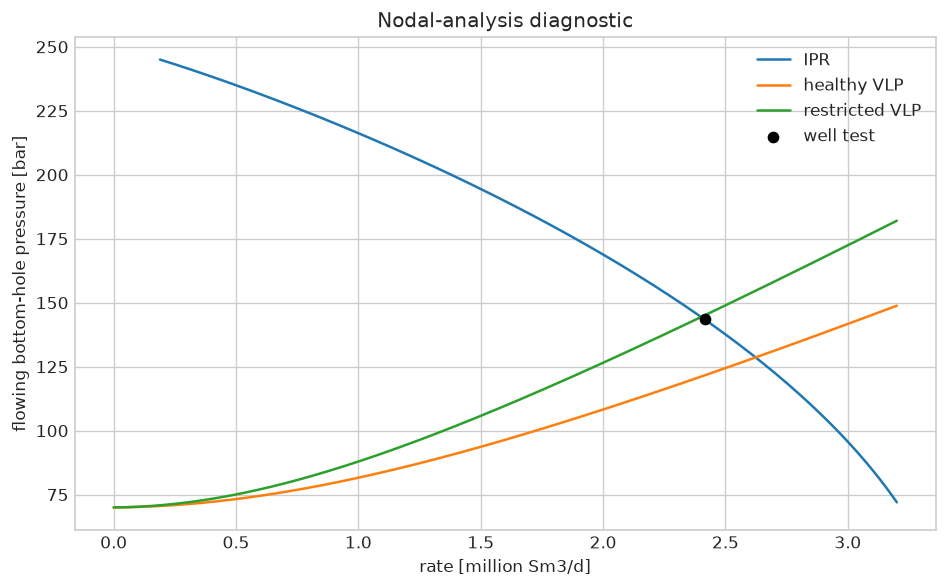

In [6]:
pwf_grid = np.linspace(72.0, 245.0, 180)
q_grid = np.linspace(0.0, ipr_rate(72.0), 180)
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(ipr_rate(pwf_grid), pwf_grid, label="IPR")
ax.plot(q_grid, vlp_pressure(q_grid), label="healthy VLP")
ax.plot(q_grid, vlp_pressure(q_grid, tubing_multiplier=1.65), label="restricted VLP")
ax.scatter(measured_rate, measured_pwf, color="black", zorder=5, label="well test")
ax.set(xlabel="rate [million Sm3/d]", ylabel="flowing bottom-hole pressure [bar]")
ax.set_title("Nodal-analysis diagnostic")
ax.legend()
plt.tight_layout()
plt.show()


In [7]:
assert ranked.iloc[0].scenario == "tubing restriction"
assert ranked.iloc[0].normalized_residual < 1.0
assert reservoir["z_factor"] > 0.5
print("VALIDATION PASSED")
print("Next check: repeat the well test at a second choke setting.")


VALIDATION PASSED
Next check: repeat the well test at a second choke setting.


## Interpretation and limits

The paired rate and flowing-pressure observation discriminates tubing
restriction from inflow loss. The equations are screening proxies;
calibrate multiphase pressure drop, PVT, geometry, and rate-dependent
skin before field action.
